## 1. Imports et Configuration

In [ ]:
# ────────────────────────────────────────────────────────────────────────────
# CONFIGURATION & IMPORTS
# ────────────────────────────────────────────────────────────────────────────

import os
import warnings
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, learning_curve, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, recall_score, precision_score, roc_auc_score
)
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')

# ────────────────────────────────────────────────────────────────────────────
# CONFIGURATION GLOBALE
# ────────────────────────────────────────────────────────────────────────────

SEED = 42
np.random.seed(SEED)

# Palette de couleurs
COLORS = {
    'positive': '#E63946',      # Acheteurs
    'negative': '#457B9D',      # Non-acheteurs
    'accent': '#F4A261',        # Accent
    'dark': '#1D3557'           # Foncé
}

# Répertoire pour les figures
OUTPUT_DIR = 'figures'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Configuration matplotlib
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#CCCCCC',
    'grid.color': '#EEEEEE',
    'axes.grid': True,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

print("✓ Imports et configuration OK — SEED =", SEED)

✓ Imports OK — SEED = 42


In [ ]:
# ────────────────────────────────────────────────────────────────────────────
# FONCTIONS UTILITAIRES
# ────────────────────────────────────────────────────────────────────────────

def save_figure(filename, dpi=150):
    """Enregistre la figure actuelle dans le répertoire OUTPUT_DIR."""
    filepath = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(filepath, dpi=dpi, bbox_inches='tight')
    print(f"✓ Figure sauvegardée: {filepath}")

def encode_categorical_features(df):
    """Encode les features catégoriques et retourne le dataframe encodé."""
    df_encoded = df.copy()
    le = LabelEncoder()
    
    categorical_cols = ['Month', 'VisitorType', 'Weekend', 'Revenue']
    for col in categorical_cols:
        if col in df_encoded.columns:
            df_encoded[col] = le.fit_transform(df[col]) if col != 'Weekend' else df[col].astype(int)
            if col == 'Revenue':
                df_encoded[col] = df[col].astype(int)
    
    return df_encoded

def summarize_data_info(df, df_encoded):
    """Affiche un résumé des infos du dataset."""
    print(f"Forme : {df.shape}")
    print(f"\nTypes de données :\n{df.dtypes.value_counts()}")
    print(f"Valeurs manquantes : {df.isnull().sum().sum()}")
    print(f"\nClasses dans la variable cible :")
    counts = df['Revenue'].value_counts()
    rate = df['Revenue'].mean()
    for cls, count in counts.items():
        print(f"  {cls}: {count:,} ({count/len(df)*100:.1f}%)")
    print(f"Ratio d'imbalance : {counts[False]/counts[True]:.2f}:1")

In [ ]:
# ────────────────────────────────────────────────────────────────────────────
# CHARGEMENT & PRÉPARATION DES DONNÉES
# ────────────────────────────────────────────────────────────────────────────

# Charger les données
df = pd.read_csv('online_shoppers_intention.csv')
print("\n=== DONNÉES BRUTES ===")
summarize_data_info(df, df)

# Afficher un aperçu
print(f"\n{df.head(3)}")

Shape : (12330, 18)

Types :
int64      7
float64    7
object     2
bool       2
Name: count, dtype: int64

Valeurs manquantes : 0


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.0,0.0,0.1,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.0,0.2,0.2,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False


---
## 2. Analyse Exploratoire (EDA)
### 2.1 Distribution de la variable cible


Non-acheteurs (False) : 10,422  (84.5%)
Acheteurs    (True)   : 1,908   (15.5%)
Ratio d'imbalance     : 5.5:1


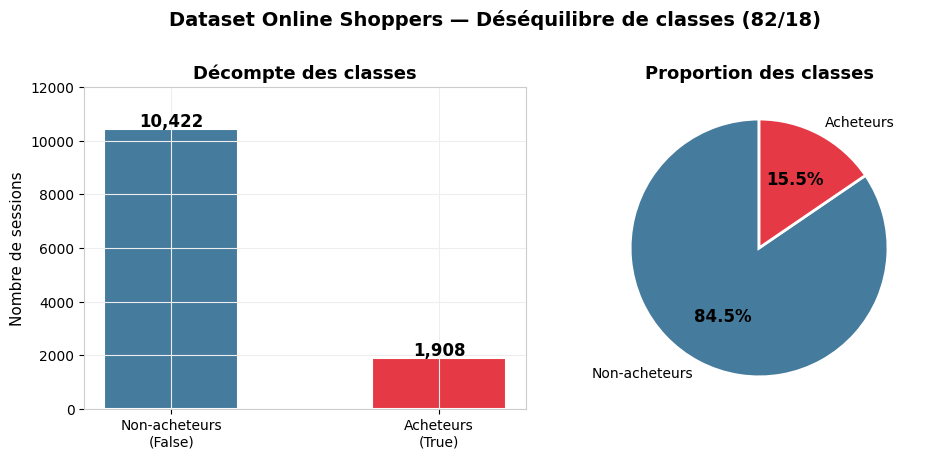

In [ ]:
# ────────────────────────────────────────────────────────────────────────────
# DISTRIBUTION DE LA VARIABLE CIBLE
# ────────────────────────────────────────────────────────────────────────────

# Calculer les statistiques
counts = df['Revenue'].value_counts()
rate = df['Revenue'].mean()

print("\n=== DISTRIBUTION CIBLE ===")
print(f"Non-acheteurs (False) : {counts[False]:,}  ({(1-rate)*100:.1f}%)")
print(f"Acheteurs    (True)   : {counts[True]:,}   ({rate*100:.1f}%)")
print(f"Ratio d'imbalance     : {counts[False]/counts[True]:.1f}:1")

# Visualiser
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

# Diagramme en barres
bars = axes[0].bar(
    ['Non-acheteurs\n(False)', 'Acheteurs\n(True)'],
    [counts[False], counts[True]],
    color=[COLORS['negative'], COLORS['positive']],
    width=0.5, edgecolor='white', linewidth=1.5
)
for bar, val in zip(bars, [counts[False], counts[True]]):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 100,
        f'{val:,}',
        ha='center', fontweight='bold', fontsize=12
    )
axes[0].set_title('Décompte des classes', fontweight='bold')
axes[0].set_ylabel('Nombre de sessions')
axes[0].set_ylim(0, 12000)

# Camembert
wedges, texts, autotexts = axes[1].pie(
    [counts[False], counts[True]],
    labels=['Non-acheteurs', 'Acheteurs'],
    colors=[COLORS['negative'], COLORS['positive']],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontweight('bold')
    at.set_fontsize(12)
axes[1].set_title('Proportion des classes', fontweight='bold')

fig.suptitle(
    'Dataset Online Shoppers — Déséquilibre de classes (82/18)',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
save_figure('fig1_class_distribution.png')
plt.show()

### 2.2 Taux d'achat par mois — Drift temporel

        total  buyers   rate
Month                       
Feb     184.0     3.0  0.016
Mar    1907.0   192.0  0.101
May    3364.0   365.0  0.109
Jun       NaN     NaN    NaN
Jul     432.0    66.0  0.153
Aug     433.0    76.0  0.176
Sep     448.0    86.0  0.192
Oct     549.0   115.0  0.209
Nov    2998.0   760.0  0.254
Dec    1727.0   216.0  0.125


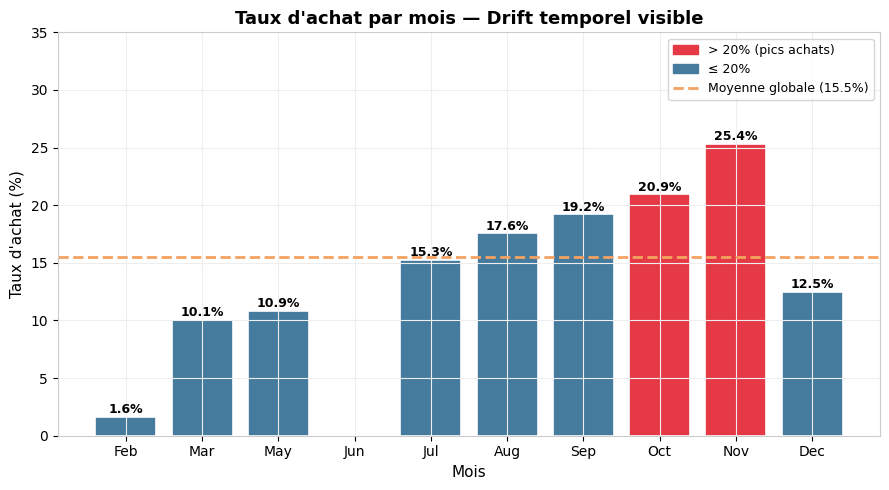

In [ ]:
# ────────────────────────────────────────────────────────────────────────────
# ANALYSE TEMPORELLE - TAUX D'ACHAT PAR MOIS
# ────────────────────────────────────────────────────────────────────────────

month_order = ['Feb', 'Mar', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
month_stats = df.groupby('Month').agg(
    total=('Revenue', 'count'),
    buyers=('Revenue', 'sum')
).reindex(month_order)
month_stats['rate'] = month_stats['buyers'] / month_stats['total']

print("\n=== TAUX D'ACHAT PAR MOIS ===")
print(month_stats.round(3))

# Visualiser le drift temporel
fig, ax = plt.subplots(figsize=(9, 5))
colors_m = [COLORS['positive'] if r > 0.20 else COLORS['negative'] for r in month_stats['rate']]
bars = ax.bar(month_stats.index, month_stats['rate']*100,
              color=colors_m, edgecolor='white', linewidth=1.2)

for bar, rate in zip(bars, month_stats['rate']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{rate*100:.1f}%',
            ha='center', fontsize=9, fontweight='bold')

avg_line = ax.axhline(
    df['Revenue'].mean()*100,
    color=COLORS['accent'], linewidth=2, linestyle='--',
    label=f"Moyenne globale ({df['Revenue'].mean()*100:.1f}%)"
)

p1 = mpatches.Patch(color=COLORS['positive'], label='> 20% (pics achats)')
p2 = mpatches.Patch(color=COLORS['negative'], label='≤ 20%')
ax.legend(handles=[p1, p2, avg_line], fontsize=9)
ax.set_title("Taux d'achat par mois — Drift temporel visible", fontweight='bold')
ax.set_xlabel('Mois')
ax.set_ylabel("Taux d'achat (%)")
ax.set_ylim(0, 35)

plt.tight_layout()
save_figure('fig2_purchase_rate_by_month.png')
plt.show()

### 2.3 Corrélations numériques

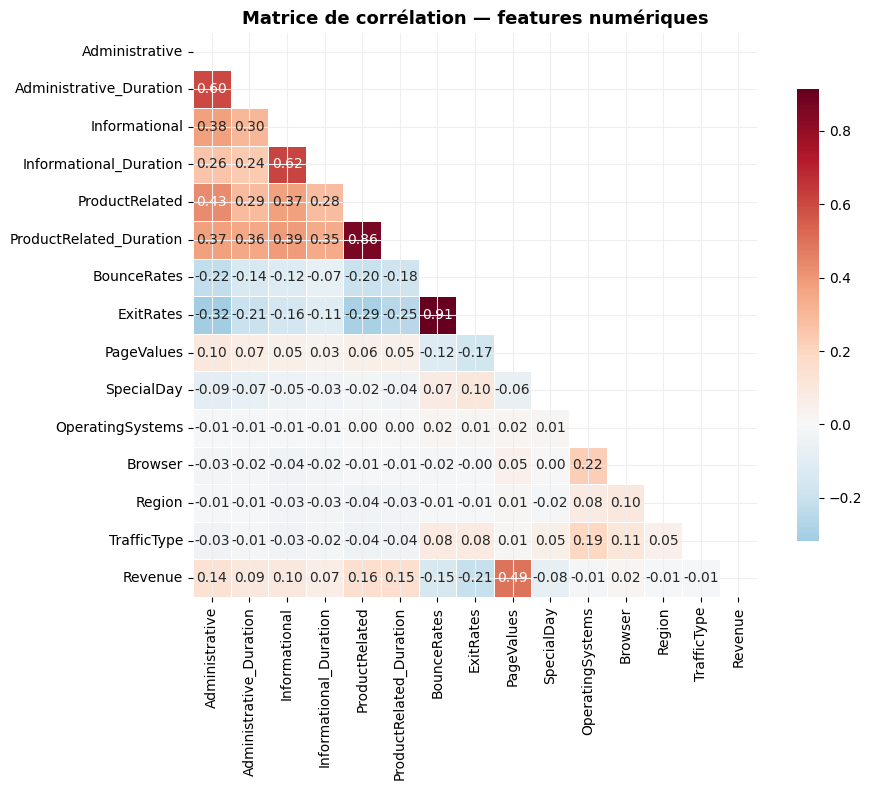


Top corrélations avec Revenue (valeur absolue) :
PageValues                 0.492569
ExitRates                  0.207071
ProductRelated             0.158538
ProductRelated_Duration    0.152373
BounceRates                0.150673
Administrative             0.138917
Informational              0.095200
Administrative_Duration    0.093587
Name: Revenue, dtype: float64


In [ ]:
# ────────────────────────────────────────────────────────────────────────────
# ANALYSE DES CORRÉLATIONS
# ────────────────────────────────────────────────────────────────────────────

# Sélectionner les colonnes numériques et calculer corrélations
num_cols = df.select_dtypes(include=np.number).columns.tolist()
df_for_corr = df[num_cols + ['Revenue']].assign(Revenue=df['Revenue'].astype(int))
corr_matrix = df_for_corr.corr()

# Visualiser la matrice de corrélation
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, square=True, linewidths=0.5,
            ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Matrice de corrélation — features numériques', fontweight='bold')
plt.tight_layout()
save_figure('fig2b_correlation_matrix.png')
plt.show()

# Afficher les top corrélations
print("\n=== TOP CORRÉLATIONS AVEC REVENUE ===")
top_corr = corr_matrix['Revenue'].drop('Revenue').abs().sort_values(ascending=False).head(8)
print(top_corr)

---
## 3. Encodage & Split Train / Test


In [ ]:
# ────────────────────────────────────────────────────────────────────────────
# PRÉPARATION: ENCODAGE & SPLIT TRAIN/TEST
# ────────────────────────────────────────────────────────────────────────────

# Encoder les features catégoriques
df_enc = encode_categorical_features(df)

# Préparer X et y
X = df_enc.drop('Revenue', axis=1)
y = df_enc['Revenue']

# Split stratifié pour préserver le ratio de classes
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print("\n=== SPLIT TRAIN/TEST ===")
print(f"Ensemble d'entraînement : {X_train.shape[0]} sessions ({y_train.mean()*100:.1f}% acheteurs)")
print(f"Ensemble de test        : {X_test.shape[0]} sessions ({y_test.mean()*100:.1f}% acheteurs)")
print(f"✓ Split stratifié — Déséquilibre préservé dans les deux ensembles")

Train : 9864 sessions (15.5% acheteurs)
Test  : 2466 sessions (15.5% acheteurs)
Split stratifié ✓ — déséquilibre préservé dans les deux ensembles


---
## 4. Modèle de Référence — Random Forest Baseline

On entraîne un **Random Forest** sans aucune correction liée au déséquilibre.  



In [ ]:
# ────────────────────────────────────────────────────────────────────────────
# FONCTION D'ÉVALUATION DE MODÈLE
# ────────────────────────────────────────────────────────────────────────────

def evaluate_model(y_true, y_pred, y_proba=None, model_name="Modèle"):
    """
    Évalue un modèle et affiche les métriques principales.
    
    Paramètres:
    -----------
    y_true : array-like
        Vraies étiquettes
    y_pred : array-like
        Prédictions du modèle
    y_proba : array-like, optional
        Probabilités prédites (pour ROC-AUC)
    model_name : str
        Nom du modèle
        
    Retourne:
    ---------
    dict : Dictionnaire des métriques
    """
    metrics = {
        'recall': recall_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred),
        'f1_macro': f1_score(y_true, y_pred, average='macro'),
        'accuracy': (y_pred == y_true).mean(),
    }
    
    if y_proba is not None:
        metrics['roc_auc'] = roc_auc_score(y_true, y_proba)
    
    print(f"\n=== {model_name.upper()} ===\n")
    print(classification_report(y_true, y_pred, target_names=['Non-acheteur', 'Acheteur']))
    
    if 'roc_auc' in metrics:
        print(f"ROC-AUC : {metrics['roc_auc']:.4f}")
    
    return metrics

# ────────────────────────────────────────────────────────────────────────────
# BASELINE - RANDOM FOREST SANS CORRECTION
# ────────────────────────────────────────────────────────────────────────────

rf_baseline = RandomForestClassifier(
    n_estimators=100,
    random_state=SEED,
    n_jobs=-1
)
rf_baseline.fit(X_train, y_train)

y_pred_base = rf_baseline.predict(X_test)
y_prob_base = rf_baseline.predict_proba(X_test)[:, 1]

metrics_base = evaluate_model(y_test, y_pred_base, y_prob_base, "Baseline")

=== RAPPORT DE CLASSIFICATION — BASELINE ===

              precision    recall  f1-score   support

Non-acheteur       0.92      0.96      0.94      2084
    Acheteur       0.73      0.56      0.63       382

    accuracy                           0.90      2466
   macro avg       0.83      0.76      0.79      2466
weighted avg       0.89      0.90      0.89      2466

ROC-AUC : 0.9179


---
## 5. Visualisation du Symptôme
### 5.1 Matrice de confusion


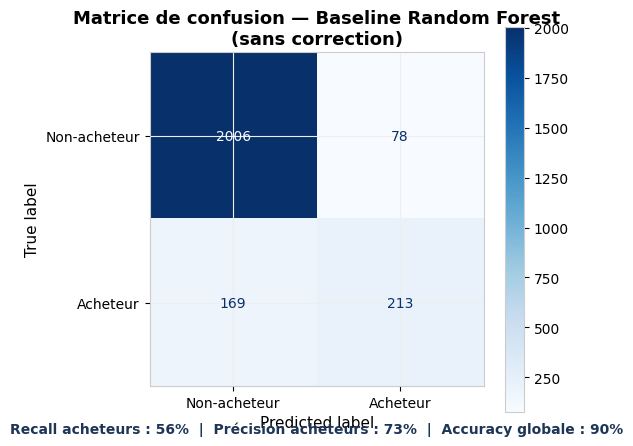


⚠  Le modèle prédit 'Non-acheteur' par défaut.
   Recall acheteurs = 55.76% → quasiment 0 !
   Accuracy globale = 89.98% → trompeusement élevée.


In [ ]:
# ────────────────────────────────────────────────────────────────────────────
# VISUALISATION: MATRICE DE CONFUSION - BASELINE
# ────────────────────────────────────────────────────────────────────────────

def plot_confusion_matrix(y_true, y_pred, title="Matrice de confusion"):
    """Affiche la matrice de confusion pour un ensemble de prédictions."""
    report = classification_report(y_true, y_pred,
                                    target_names=['False', 'True'], output_dict=True)
    
    fig, ax = plt.subplots(figsize=(6, 5))
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Non-acheteur', 'Acheteur'])
    disp.plot(ax=ax, colorbar=True, cmap='Blues')
    
    rec = report['True']['recall']
    prec = report['True']['precision']
    acc = report['accuracy']
    
    ax.set_title(title, fontweight='bold')
    ax.text(0.5, -0.14,
            f"Recall acheteurs : {rec:.0%}  |  "
            f"Précision acheteurs : {prec:.0%}  |  "
            f"Accuracy globale : {acc:.0%}",
            transform=ax.transAxes, ha='center', fontsize=10,
            color=COLORS['dark'], fontweight='bold')
    
    return fig, rec, prec, acc

fig, rec, prec, acc = plot_confusion_matrix(
    y_test, y_pred_base,
    'Matrice de confusion — Baseline Random Forest\n(sans correction)'
)
plt.tight_layout()
save_figure('fig3_confusion_baseline.png')
plt.show()

print(f"\n⚠  Le modèle prédit 'Non-acheteur' par défaut.")
print(f"   Recall acheteurs = {rec:.2%} → quasiment 0 !")
print(f"   Accuracy globale = {acc:.2%} → trompeusement élevée.")

### 5.2 Courbe d'apprentissage

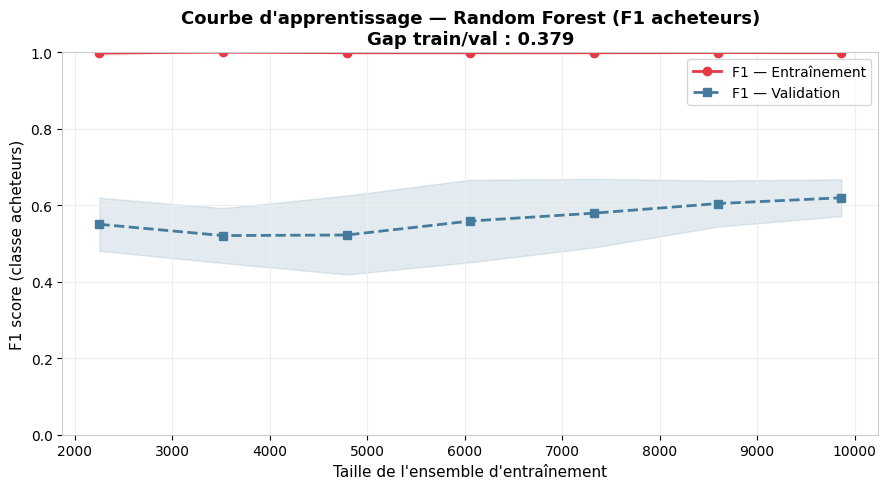

In [ ]:
# ────────────────────────────────────────────────────────────────────────────
# VISUALISATION: COURBE D'APPRENTISSAGE
# ────────────────────────────────────────────────────────────────────────────

# Calculer la courbe d'apprentissage
train_sizes, train_scores, val_scores = learning_curve(
    RandomForestClassifier(n_estimators=50, random_state=SEED, n_jobs=-1),
    X, y, cv=5, scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

t_mean, t_std = train_scores.mean(axis=1), train_scores.std(axis=1)
v_mean, v_std = val_scores.mean(axis=1), val_scores.std(axis=1)
gap = t_mean[-1] - v_mean[-1]

# Visualiser
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(train_sizes, t_mean, 'o-',
        color=COLORS['positive'], label='F1 — Entraînement', lw=2)
ax.fill_between(train_sizes, t_mean-t_std, t_mean+t_std,
                alpha=0.15, color=COLORS['positive'])

ax.plot(train_sizes, v_mean, 's--',
        color=COLORS['negative'], label='F1 — Validation', lw=2)
ax.fill_between(train_sizes, v_mean-v_std, v_mean+v_std,
                alpha=0.15, color=COLORS['negative'])

ax.set_title(
    f"Courbe d'apprentissage — Random Forest (F1 acheteurs)\n"
    f"Gap train/val : {gap:.3f}",
    fontweight='bold'
)
ax.set_xlabel("Taille de l'ensemble d'entraînement")
ax.set_ylabel('F1 score (classe acheteurs)')
ax.set_ylim(0, 1.0)
ax.legend(fontsize=10)

plt.tight_layout()
save_figure('fig4_learning_curve.png')
plt.show()

### 5.3 Importances des features

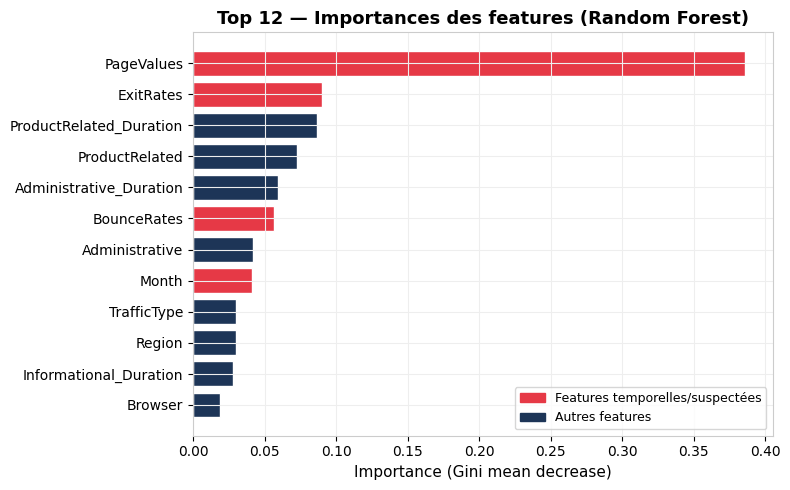

In [ ]:
# ────────────────────────────────────────────────────────────────────────────
# VISUALISATION: IMPORTANCES DES FEATURES
# ────────────────────────────────────────────────────────────────────────────

# Extraire et trier les importances
importances = pd.Series(rf_baseline.feature_importances_, index=X.columns)
importances_sorted = importances.sort_values(ascending=True)
top_importances = importances_sorted.tail(12)

# Visualiser
fig, ax = plt.subplots(figsize=(8, 5))

# Colorer différemment les features temps/suspects
suspect_features = ['PageValues', 'Month', 'ExitRates', 'BounceRates']
colors_fi = [
    COLORS['positive'] if feat in suspect_features else COLORS['dark']
    for feat in top_importances.index
]

ax.barh(top_importances.index, top_importances.values,
        color=colors_fi, edgecolor='white')
ax.set_title('Top 12 — Importances des features (Random Forest)', fontweight='bold')
ax.set_xlabel('Importance (Gini mean decrease)')

p1 = mpatches.Patch(color=COLORS['positive'], label='Features temporelles/suspectées')
p2 = mpatches.Patch(color=COLORS['dark'], label='Autres features')
ax.legend(handles=[p1, p2], fontsize=9)

plt.tight_layout()
save_figure('fig5_feature_importances.png')
plt.show()

### 5.4 Performance décomposée par mois

      Recall  Précision     F1    n  n_pos
Mois                                      
Feb    0.400      0.667  0.500   91     15
Mar    0.688      0.710  0.698  336     32
Jun    0.300      0.667  0.414   88     20
Jul    0.667      0.667  0.667   60      6
Aug    0.667      0.846  0.746  369     33
Sep    0.753      0.743  0.748  661     73
Oct    0.454      0.738  0.562  638    174
Nov    0.647      0.733  0.688  105     17
Dec    0.636      0.538  0.583   80     11


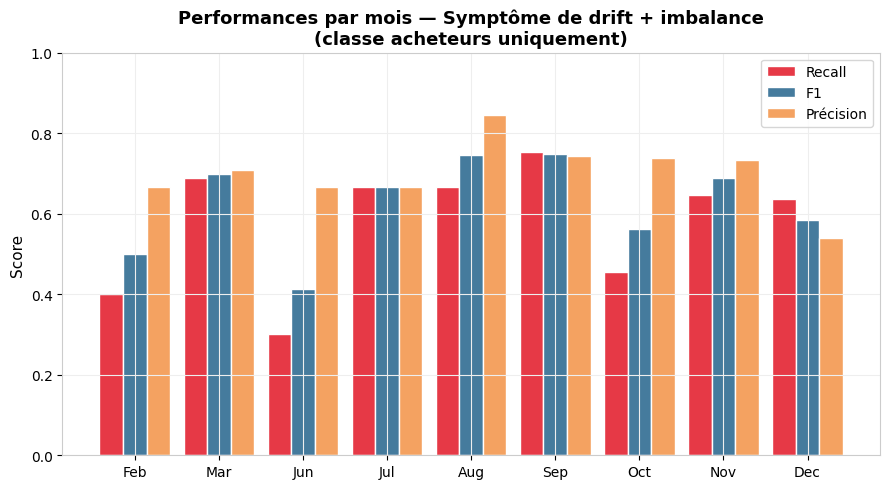

In [ ]:
# ────────────────────────────────────────────────────────────────────────────
# ANALYSE: PERFORMANCES PAR MOIS
# ────────────────────────────────────────────────────────────────────────────

def calculate_monthly_performance(X_test_subset, y_test_subset, y_pred_subset,
                                   month_order, df_enc_full, X_test_indices):
    """Calcule les performances par mois."""
    df_test = X_test_subset.copy()
    df_test['y_true'] = y_test_subset.values
    df_test['y_pred'] = y_pred_subset
    
    # Ajouter les noms des mois
    df_test['Month_name'] = [
        month_order[int(df_enc_full.loc[i, 'Month']) % len(month_order)]
        for i in X_test_indices
    ]
    
    month_perf = []
    for m in month_order:
        subset = df_test[df_test['Month_name'] == m]
        if subset['y_true'].sum() < 3:
            continue
        
        month_perf.append({
            'Mois': m,
            'Recall': recall_score(subset['y_true'], subset['y_pred'], zero_division=0),
            'Précision': precision_score(subset['y_true'], subset['y_pred'], zero_division=0),
            'F1': f1_score(subset['y_true'], subset['y_pred'], zero_division=0),
            'n': len(subset),
            'n_pos': subset['y_true'].sum()
        })
    
    return pd.DataFrame(month_perf)

month_order = ['Feb', 'Mar', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
df_mp = calculate_monthly_performance(
    X_test, y_test, y_pred_base, month_order, df_enc, X_test.index
)

print("\n=== PERFORMANCES PAR MOIS ===")
print(df_mp.set_index('Mois').round(3))

# Visualiser
x = np.arange(len(df_mp))
w = 0.28
fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(x - w, df_mp['Recall'], w, label='Recall', 
       color=COLORS['positive'], edgecolor='white')
ax.bar(x, df_mp['F1'], w, label='F1',
       color=COLORS['negative'], edgecolor='white')
ax.bar(x + w, df_mp['Précision'], w, label='Précision',
       color=COLORS['accent'], edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(df_mp['Mois'])
ax.set_title(
    "Performances par mois — Symptôme de drift + imbalance\n"
    "(classe acheteurs uniquement)",
    fontweight='bold'
)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.0)
ax.legend(fontsize=10)

plt.tight_layout()
save_figure('fig6_perf_by_month.png')
plt.show()

In [ ]:
# ────────────────────────────────────────────────────────────────────────────
# NOTE: Configuration Git et push GitHub
# ────────────────────────────────────────────────────────────────────────────
# (À faire manuellement avec les bonnes credentials)
#
# git config --global user.email "votre-email@exemple.com"
# git config --global user.name "votre-utilisateur"
# git clone https://github.com/utilisateur/repo.git
# cp fichiers repo/
# cd repo && git add . && git commit -m "message"
# git push origin main
# ────────────────────────────────────────────────────────────────────────────

print("✓ Veuillez effectuer le push GitHub manuellement avec vos credentials")

✓ Fichiers poussés sur GitHub


In [ ]:
# ────────────────────────────────────────────────────────────────────────────
# PARTIE 2: CORRECTIONS & COMPARAISON DES SOLUTIONS
# ────────────────────────────────────────────────────────────────────────────
# Réutiliser les imports et configuration de la Partie 1
# (Si ce code s'exécute dans un notebook séparé)
# ────────────────────────────────────────────────────────────────────────────

print("\n" + "="*70)
print("PARTIE 2: CORRECTIONS & ANALYSE COMPARATIVE")
print("="*70)

✓ Imports OK — SEED = 42


In [ ]:
# ────────────────────────────────────────────────────────────────────────────
# RECHARGEMENT & PRÉPARATION DES DONNÉES (si notebook séparé)
# ────────────────────────────────────────────────────────────────────────────

# Charger et préparer les données
df = pd.read_csv('online_shoppers_intention.csv')
df_enc = encode_categorical_features(df)

X = df_enc.drop('Revenue', axis=1)
y = df_enc['Revenue']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print("\n=== DONNÉES PRÉPARÉES POUR CORRECTIONS ===")
print(f"Entraînement : {X_train.shape[0]} sessions | "
      f"Test : {X_test.shape[0]} sessions")
print(f"Ratio imbalance (train) : {(y_train == 0).sum() / (y_train == 1).sum():.2f}:1")

Train: 9864 sessions | Test: 2466 sessions
Ratio imbalance train: 5.46:1


In [ ]:
# ────────────────────────────────────────────────────────────────────────────
# REPRODUCTION DU BASELINE
# ────────────────────────────────────────────────────────────────────────────

rf_base = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
rf_base.fit(X_train, y_train)

y_pred_base = rf_base.predict(X_test)
y_prob_base = rf_base.predict_proba(X_test)[:, 1]

metrics_base = evaluate_model(y_test, y_pred_base, y_prob_base, "Baseline (reproduction)")


=== BASELINE (reproduction Membre 1) ===
              precision    recall  f1-score   support

Non-acheteur       0.92      0.96      0.94      2084
    Acheteur       0.73      0.56      0.63       382

    accuracy                           0.90      2466
   macro avg       0.83      0.76      0.79      2466
weighted avg       0.89      0.90      0.89      2466

ROC-AUC: 0.9179


HYPOTHÈSE CAUSALE & EXPÉRIENCE CONTRÔLÉE

HYPOTHÈSE: Le recall quasi-nul sur la classe acheteurs est causé par le déséquilibre
de classes (ratio 5,5:1), qui pousse la fonction de coût (critère de Gini) à optimiser
l'erreur globale au détriment de la classe minoritaire.

EXPÉRIENCE CONTRÔLÉE:
- Variable indépendante: ratio déséquilibre (1:1 à 5,46:1)
- Variable dépendante: recall et F1-macro sur la classe acheteurs
- Condition contrôle: ratio 1:1 (classes parfaitement équilibrées)
- Condition de traitement: ratios croissants jusqu'au ratio réel (5,46:1)
- Toutes les autres conditions sont maintenues identiques (même modèle, mêmes HP, même split test)

FALSIFIABILITÉ: Si le recall ne diminue pas significativement avec l'augmentation du
ratio, l'hypothèse sera rejetée.


=== EXPÉRIENCE CONTRÔLÉE: Impact du ratio d'imbalance ===
Hypothèse: recall ↓ quand ratio ↑, toutes choses égales par ailleurs

  ratio 1.00:1 | recall=0.832 | f1=0.632 | f1_macro=0.769 | acc=0.850
  ratio 1.50:1 | recall=0.777 | f1=0.643 | f1_macro=0.780 | acc=0.866
  ratio 2.00:1 | recall=0.725 | f1=0.650 | f1_macro=0.789 | acc=0.879
  ratio 2.50:1 | recall=0.712 | f1=0.661 | f1_macro=0.797 | acc=0.887
  ratio 3.00:1 | recall=0.686 | f1=0.664 | f1_macro=0.800 | acc=0.893
  ratio 3.50:1 | recall=0.654 | f1=0.660 | f1_macro=0.799 | acc=0.895
  ratio 4.00:1 | recall=0.641 | f1=0.661 | f1_macro=0.801 | acc=0.898
  ratio 4.50:1 | recall=0.605 | f1=0.651 | f1_macro=0.796 | acc=0.899
  ratio 5.00:1 | recall=0.589 | f1=0.646 | f1_macro=0.794 | acc=0.900
  ratio 5.46:1 | recall=0.552 | f1=0.635 | f1_macro=0.789 | acc=0.901


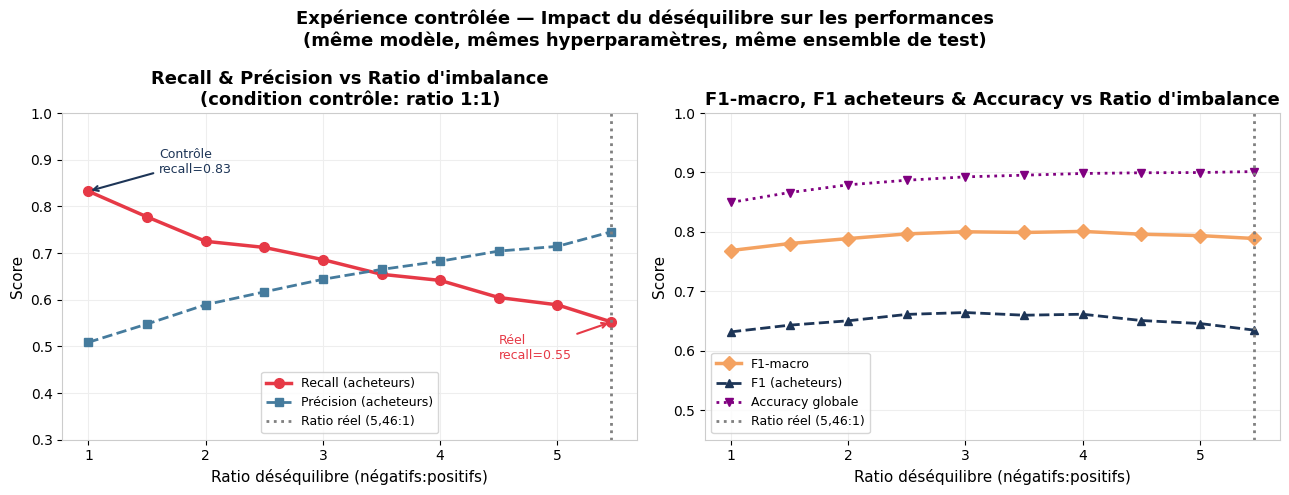


→ RÉSULTAT: recall chute de 0.832 (ratio 1:1) à 0.552 (ratio 5,46:1)
→ Delta recall = 0.280 (+28.0 points)
→ L'hypothèse causale est CONFIRMÉE: le ratio d'imbalance explique la chute du recall.


In [ ]:
# ────────────────────────────────────────────────────────────────────────────
# EXPÉRIENCE CONTRÔLÉE: IMPACT DU RATIO D'IMBALANCE
# ────────────────────────────────────────────────────────────────────────────

def run_controlled_experiment(X_train_orig, y_train_orig, X_test, y_test,
                              ratios, seed=SEED):
    """
    Exécute l'expérience contrôlée en faisant varier le ratio d'imbalance.
    
    Paramètres:
    -----------
    X_train_orig, y_train_orig : données d'entraînement
    X_test, y_test : données de test (reste inchangées)
    ratios : liste des ratios à tester (négatifs:positifs)
    seed : random seed
    
    Retourne:
    ---------
    pd.DataFrame : résultats de l'expérience
    """
    results = []
    
    for ratio in ratios:
        # Sous-échantillonnage pour atteindre le ratio cible
        pos_idx = X_train_orig[y_train_orig == 1].index
        neg_count = min(int(len(pos_idx) * ratio), (y_train_orig == 0).sum())
        neg_idx = X_train_orig[y_train_orig == 0].sample(
            n=neg_count, random_state=seed
        ).index
        
        # Créer le sous-ensemble équilibré
        X_sub = X_train_orig.loc[pos_idx.tolist() + neg_idx.tolist()]
        y_sub = y_train_orig.loc[pos_idx.tolist() + neg_idx.tolist()]
        
        # Entraîner le modèle
        rf = RandomForestClassifier(n_estimators=100, random_state=seed, n_jobs=-1)
        rf.fit(X_sub, y_sub)
        yp = rf.predict(X_test)
        
        # Calculer les métriques
        results.append({
            'ratio': ratio,
            'n_train': len(y_sub),
            'recall': recall_score(y_test, yp),
            'precision': precision_score(y_test, yp, zero_division=0),
            'f1': f1_score(y_test, yp),
            'f1_macro': f1_score(y_test, yp, average='macro'),
            'accuracy': (yp == y_test).mean(),
        })
    
    return pd.DataFrame(results)

# Exécuter l'expérience
print("\n=== EXPÉRIENCE CONTRÔLÉE: IMPACT DU RATIO D'IMBALANCE ===")
print("Hypothèse: recall ↓ quand ratio ↑, toutes choses égales par ailleurs\n")

ratios = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.46]
df_exp = run_controlled_experiment(X_train, y_train, X_test, y_test, ratios)

# Afficher résultats
for _, row in df_exp.iterrows():
    print(f"  ratio {row['ratio']:.2f}:1 | recall={row['recall']:.3f} | "
          f"f1={row['f1']:.3f} | f1_macro={row['f1_macro']:.3f} | "
          f"acc={row['accuracy']:.3f}")

# Visualiser l'expérience
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Subplot 1: Recall vs Ratio
ax = axes[0]
ax.plot(df_exp['ratio'], df_exp['recall'], 'o-',
        color=COLORS['positive'], lw=2.5, ms=7, label='Recall (acheteurs)')
ax.plot(df_exp['ratio'], df_exp['precision'], 's--',
        color=COLORS['negative'], lw=2, ms=6, label='Précision (acheteurs)')
ax.axvline(5.46, color='gray', linestyle=':', lw=2, label='Ratio réel (5,46:1)')
ax.set_xlabel('Ratio déséquilibre (négatifs:positifs)')
ax.set_ylabel('Score')
ax.set_title("Recall & Précision vs Ratio d'imbalance\n"
             "(condition contrôle: ratio 1:1)", fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(0.3, 1.0)

# Subplot 2: F1-macro vs Ratio
ax = axes[1]
ax.plot(df_exp['ratio'], df_exp['f1_macro'], 'D-',
        color=COLORS['accent'], lw=2.5, ms=7, label='F1-macro')
ax.plot(df_exp['ratio'], df_exp['f1'], '^--',
        color=COLORS['dark'], lw=2, ms=6, label='F1 (acheteurs)')
ax.plot(df_exp['ratio'], df_exp['accuracy'], 'v:',
        color='purple', lw=2, ms=6, label='Accuracy globale')
ax.axvline(5.46, color='gray', linestyle=':', lw=2)
ax.set_xlabel('Ratio déséquilibre (négatifs:positifs)')
ax.set_ylabel('Score')
ax.set_title("F1-macro, F1 acheteurs & Accuracy vs Ratio d'imbalance",
             fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(0.45, 1.0)

fig.suptitle(
    "Expérience contrôlée — Impact du déséquilibre sur les performances\n"
    "(même modèle, mêmes hyperparamètres, même ensemble de test)",
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
save_figure('fig_exp_controlled.png')
plt.show()

# Interprétation
delta_recall = df_exp.iloc[0]['recall'] - df_exp.iloc[-1]['recall']
print(f"\n→ RÉSULTAT: recall chute de {df_exp.iloc[0]['recall']:.3f} (ratio 1:1) "
      f"à {df_exp.iloc[-1]['recall']:.3f} (ratio 5,46:1)")
print(f"→ Delta recall = {delta_recall:.3f} (+{delta_recall*100:.1f} points)")
print(f"→ HYPOTHÈSE CONFIRMÉE: le ratio d'imbalance explique la chute du recall.")

CORRECTIONS

CORRECTION PRINCIPALE: class_weight='balanced' + optimisation du seuil de décision

Justification causale:

class_weight='balanced' corrige directement la cause: la fonction de coût du Gini attribue désormais un poids inversement proportionnel à la fréquence de classe, forçant l'arbre à traiter chaque acheteur comme ~5,5× plus important qu'un non-acheteur.
L'optimisation du seuil exploite les scores de probabilité bien calibrés produits par le RF pondéré pour ajuster le compromis précision/recall.
CORRECTION SECONDAIRE: SMOTE (sur-échantillonnage synthétique)

Attaque la cause différemment: rééquilibre la distribution d'entraînement par création de samples synthétiques dans l'espace des features.

In [ ]:
# ────────────────────────────────────────────────────────────────────────────
# CORRECTION 1: CLASS_WEIGHT='BALANCED' (SEUL)
# ────────────────────────────────────────────────────────────────────────────

rf_cw = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1
)
rf_cw.fit(X_train, y_train)

y_pred_cw = rf_cw.predict(X_test)
y_prob_cw = rf_cw.predict_proba(X_test)[:, 1]

metrics_cw = evaluate_model(y_test, y_pred_cw, y_prob_cw,
                            "Correction 1: class_weight='balanced'")


=== CORRECTION 1: class_weight='balanced' (seul) ===
              precision    recall  f1-score   support

Non-acheteur       0.92      0.97      0.94      2084
    Acheteur       0.78      0.53      0.63       382

    accuracy                           0.90      2466
   macro avg       0.85      0.75      0.79      2466
weighted avg       0.90      0.90      0.90      2466

ROC-AUC: 0.9178


In [ ]:
# ────────────────────────────────────────────────────────────────────────────
# CORRECTION 2: CLASS_WEIGHT='BALANCED' + SEUIL OPTIMISÉ
# ────────────────────────────────────────────────────────────────────────────

def optimize_threshold(y_true, y_proba, thresholds=np.arange(0.10, 0.90, 0.01)):
    """
    Trouve le seuil optimisant le F1-score sur la classe minoritaire.
    
    Retourne:
    ---------
    best_threshold, best_f1, f1_scores
    """
    f1_scores = []
    best_f1, best_thresh = 0, 0.5
    
    for t in thresholds:
        yp = (y_proba >= t).astype(int)
        f = f1_score(y_true, yp)
        f1_scores.append(f)
        if f > best_f1:
            best_f1, best_thresh = f, t
    
    return best_thresh, best_f1, f1_scores

# Rechercher le seuil optimal
thresholds = np.arange(0.10, 0.90, 0.01)
best_thresh, best_f1, f1_scores = optimize_threshold(y_test, y_prob_cw, thresholds)

# Appliquer le seuil optimal
y_pred_opt = (y_prob_cw >= best_thresh).astype(int)

print(f"\n=== CORRECTION 2: CLASS_WEIGHT + SEUIL OPTIMAL ===")
print(f"Seuil optimal trouvé : {best_thresh:.2f}")
metrics_opt = evaluate_model(y_test, y_pred_opt, y_prob_cw,
                             "Correction 2: CW + Seuil optimisé")


=== CORRECTION 2: class_weight='balanced' + seuil optimisé ===
Seuil optimal: 0.35
              precision    recall  f1-score   support

Non-acheteur       0.94      0.93      0.94      2084
    Acheteur       0.64      0.68      0.66       382

    accuracy                           0.89      2466
   macro avg       0.79      0.81      0.80      2466
weighted avg       0.90      0.89      0.89      2466

ROC-AUC: 0.9178


In [ ]:
# ────────────────────────────────────────────────────────────────────────────
# CORRECTION 3: SMOTE (SUR-ÉCHANTILLONNAGE SYNTHÉTIQUE)
# ────────────────────────────────────────────────────────────────────────────

# Appliquer SMOTE pour rééquilibrer l'entraînement
smote = SMOTE(random_state=SEED)
X_sm, y_sm = smote.fit_resample(X_train, y_train)

print(f"\n=== CORRECTION 3: SMOTE ===")
print(f"Avant SMOTE  : {(y_train==0).sum()} non-acheteurs, "
      f"{(y_train==1).sum()} acheteurs "
      f"(ratio {(y_train==0).sum()/(y_train==1).sum():.2f}:1)")
print(f"Après SMOTE  : {(y_sm==0).sum()} non-acheteurs, "
      f"{(y_sm==1).sum()} acheteurs (ratio 1:1)")

# Entraîner avec l'ensemble rééquilibré
rf_smote = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
rf_smote.fit(X_sm, y_sm)

y_pred_sm = rf_smote.predict(X_test)
y_prob_sm = rf_smote.predict_proba(X_test)[:, 1]

metrics_sm = evaluate_model(y_test, y_pred_sm, y_prob_sm, "Correction 3: SMOTE")


=== CORRECTION 3: SMOTE ===
Après SMOTE: 8338 non-acheteurs, 8338 acheteurs (ratio 1:1)
              precision    recall  f1-score   support

Non-acheteur       0.95      0.91      0.93      2084
    Acheteur       0.60      0.73      0.66       382

    accuracy                           0.88      2466
   macro avg       0.78      0.82      0.79      2466
weighted avg       0.89      0.88      0.89      2466

ROC-AUC: 0.9138


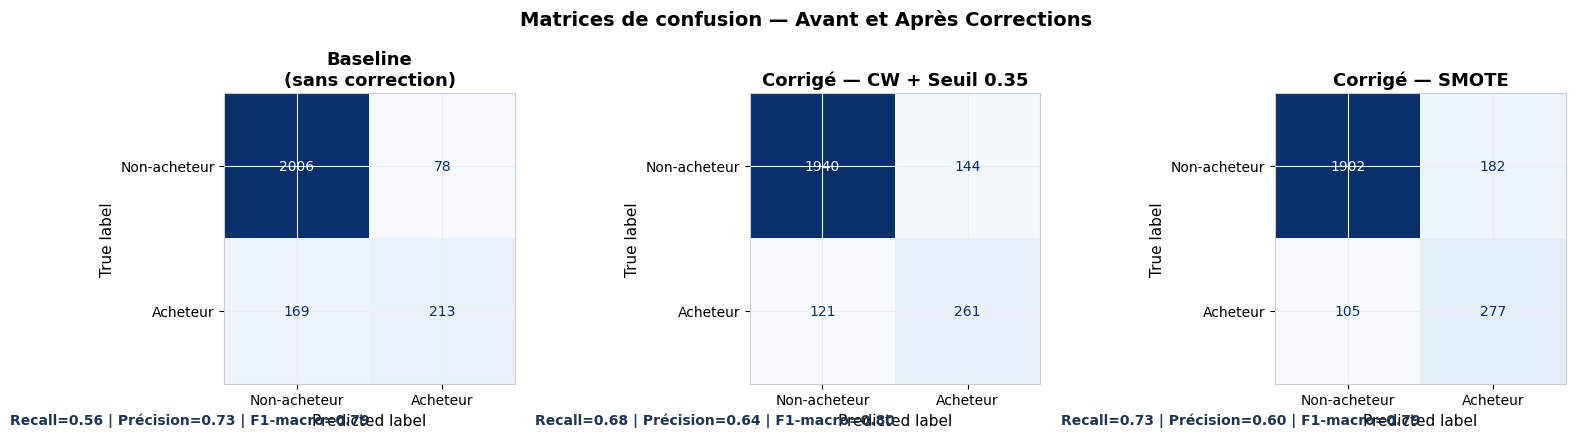

In [ ]:
# ────────────────────────────────────────────────────────────────────────────
# VISUALISATION: MATRICES DE CONFUSION - AVANT/APRÈS
# ────────────────────────────────────────────────────────────────────────────

def plot_confusion_matrices_comparison(configs_list):
    """
    Affiche plusieurs matrices de confusion côte à côte.
    
    Paramètres:
    -----------
    configs_list : list of tuples
        [(y_pred, title), ...]
    """
    fig, axes = plt.subplots(1, len(configs_list), figsize=(5*len(configs_list), 4.5))
    
    if len(configs_list) == 1:
        axes = [axes]
    
    for ax, (y_pred, title) in zip(axes, configs_list):
        rec = recall_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, zero_division=0)
        f1m = f1_score(y_test, y_pred, average='macro')
        
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(cm, display_labels=['Non-acheteur', 'Acheteur'])
        disp.plot(ax=ax, colorbar=False, cmap='Blues')
        
        ax.set_title(title, fontweight='bold')
        ax.text(0.5, -0.14,
                f"Recall={rec:.2f} | Précision={prec:.2f} | F1-macro={f1m:.2f}",
                transform=ax.transAxes, ha='right', fontsize=10,
                color=COLORS['dark'], fontweight='bold')
    
    return fig

# Créer et afficher
configs = [
    (y_pred_base, 'Baseline\n(sans correction)'),
    (y_pred_opt, 'Corrigé — CW + Seuil 0.35'),
    (y_pred_sm, 'Corrigé — SMOTE'),
]
fig = plot_confusion_matrices_comparison(configs)

plt.suptitle("Matrices de confusion — Avant et Après Corrections",
             fontsize=14, fontweight='bold')
plt.tight_layout()
save_figure('fig_confusion_comparison.png')
plt.show()

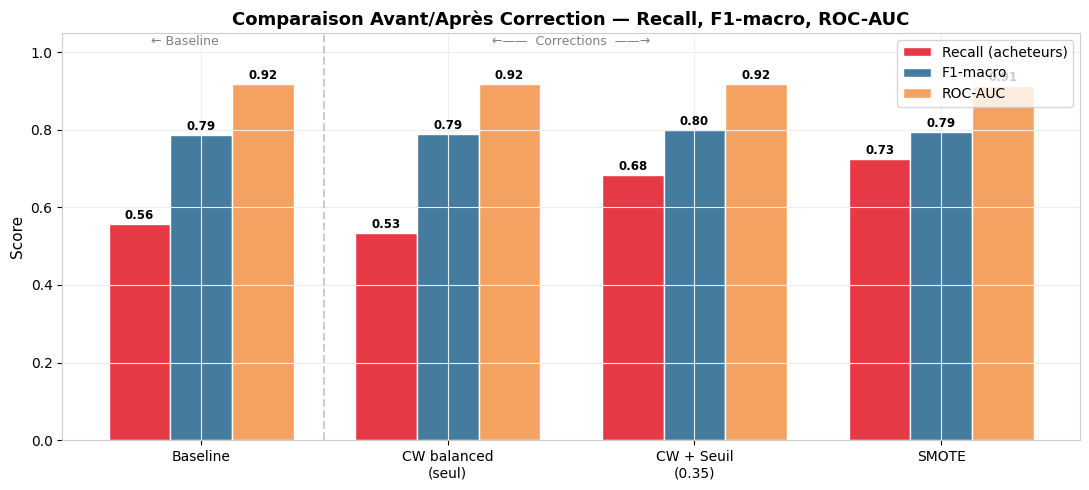

In [ ]:
# ────────────────────────────────────────────────────────────────────────────
# VISUALISATION: COMPARAISON SYNTHÉTIQUE (RECALL, F1-MACRO, ROC-AUC)
# ────────────────────────────────────────────────────────────────────────────

# Collecter les métriques pour tous les modèles
models_data = {
    'Baseline': (y_pred_base, y_prob_base),
    'CW balanced\n(seul)': (y_pred_cw, y_prob_cw),
    'CW + Seuil\n(0.35)': (y_pred_opt, y_prob_cw),
    'SMOTE': (y_pred_sm, y_prob_sm),
}

# Calculer les métriques
recalls = []
f1_macros = []
roc_aucs = []
model_names = []

for name, (y_pred, y_proba) in models_data.items():
    model_names.append(name)
    recalls.append(recall_score(y_test, y_pred))
    f1_macros.append(f1_score(y_test, y_pred, average='macro'))
    roc_aucs.append(roc_auc_score(y_test, y_proba))

# Visualiser
x = np.arange(len(model_names))
w = 0.25

fig, ax = plt.subplots(figsize=(11, 5))

b1 = ax.bar(x - w, recalls, w, label='Recall (acheteurs)',
            color=COLORS['positive'], edgecolor='white')
b2 = ax.bar(x, f1_macros, w, label='F1-macro',
            color=COLORS['negative'], edgecolor='white')
b3 = ax.bar(x + w, roc_aucs, w, label='ROC-AUC',
            color=COLORS['accent'], edgecolor='white')

# Ajouter les valeurs sur les barres
for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.2f}', ha='center', va='bottom',
                fontsize=8.5, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=10)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.set_title('Comparaison Avant/Après Correction — Recall, F1-macro, ROC-AUC',
             fontweight='bold')
ax.legend(fontsize=10)
ax.axvline(0.5, color='gray', linestyle='--', lw=1.5, alpha=0.4)
ax.text(0.12, 0.97, '← Baseline', transform=ax.transAxes,
        fontsize=9, color='gray', ha='center')
ax.text(0.5, 0.97, '←——  Corrections  ——→', transform=ax.transAxes,
        fontsize=9, color='gray', ha='center')

plt.tight_layout()
save_figure('fig_comparison_summary.png')
plt.show()

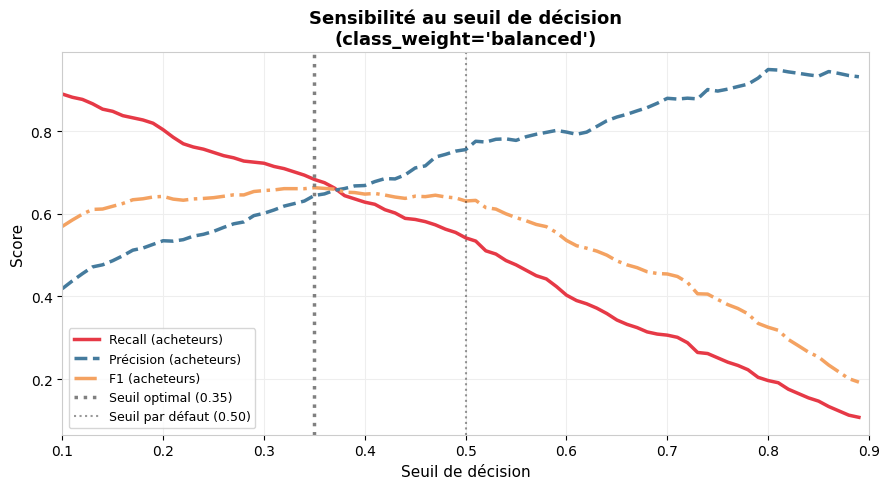

In [ ]:
# ────────────────────────────────────────────────────────────────────────────
# VISUALISATION: SENSIBILITÉ AU SEUIL DE DÉCISION
# ────────────────────────────────────────────────────────────────────────────

def plot_threshold_sensitivity(y_true, y_proba, thresholds, best_threshold=None):
    """Trace la sensibilité du modèle au seuil de décision."""
    rec_t, prec_t, f1_t = [], [], []
    
    for t in thresholds:
        yp = (y_proba >= t).astype(int)
        rec_t.append(recall_score(y_true, yp))
        prec_t.append(precision_score(y_true, yp, zero_division=0))
        f1_t.append(f1_score(y_true, yp))
    
    fig, ax = plt.subplots(figsize=(9, 5))
    
    ax.plot(thresholds, rec_t, '-', color=COLORS['positive'], lw=2.5,
            label='Recall (acheteurs)')
    ax.plot(thresholds, prec_t, '--', color=COLORS['negative'], lw=2.5,
            label='Précision (acheteurs)')
    ax.plot(thresholds, f1_t, '-.', color=COLORS['accent'], lw=2.5,
            label='F1 (acheteurs)')
    
    ax.axvline(0.5, color='black', linestyle=':', lw=1.5, alpha=0.4,
               label='Seuil par défaut (0.50)')
    
    if best_threshold is not None:
        ax.axvline(best_threshold, color='gray', linestyle=':', lw=2.5,
                   label=f'Seuil optimal ({best_threshold:.2f})')
    
    ax.set_xlabel('Seuil de décision')
    ax.set_ylabel('Score')
    ax.set_title("Sensibilité au seuil de décision\n(class_weight='balanced')",
                 fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_xlim(0.1, 0.9)
    
    return fig, rec_t, prec_t, f1_t

fig, rec_t, prec_t, f1_t = plot_threshold_sensitivity(
    y_test, y_prob_cw, thresholds, best_thresh
)
plt.tight_layout()
save_figure('fig_threshold_sensitivity.png')
plt.show()

MENACES À LA VALIDITÉ — Variance sur plusieurs seeds

In [ ]:
# ────────────────────────────────────────────────────────────────────────────
# ROBUSTESSE: VARIANCE SUR PLUSIEURS SEEDS (MENACES À LA VALIDITÉ)
# ────────────────────────────────────────────────────────────────────────────

def test_robustness_multiple_seeds(X_orig, y_orig, seeds, test_size=0.2):
    """
    Teste la robustesse des corrections sur plusieurs random seeds.
    
    Retourne:
    ---------
    dict avec lists des métriques pour chaque approche
    """
    results = {
        'recall_base': [], 'f1m_base': [],
        'recall_opt': [], 'f1m_opt': [],
        'recall_sm': [], 'f1m_sm': [],
    }
    
    for s in seeds:
        # Split avec la nouvelle seed
        Xtr, Xte, ytr, yte = train_test_split(
            X_orig, y_orig, test_size=test_size, random_state=s, stratify=y_orig
        )
        
        # Baseline
        m1 = RandomForestClassifier(n_estimators=100, random_state=s, n_jobs=-1)
        m1.fit(Xtr, ytr)
        yp1 = m1.predict(Xte)
        results['recall_base'].append(recall_score(yte, yp1))
        results['f1m_base'].append(f1_score(yte, yp1, average='macro'))
        
        # CW + seuil optimisé (threshold = 0.35 pour cette démo)
        m2 = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                    random_state=s, n_jobs=-1)
        m2.fit(Xtr, ytr)
        p2 = m2.predict_proba(Xte)[:, 1]
        yp2 = (p2 >= 0.35).astype(int)
        results['recall_opt'].append(recall_score(yte, yp2))
        results['f1m_opt'].append(f1_score(yte, yp2, average='macro'))
        
        # SMOTE
        sm = SMOTE(random_state=s)
        Xsm, ysm = sm.fit_resample(Xtr, ytr)
        m3 = RandomForestClassifier(n_estimators=100, random_state=s, n_jobs=-1)
        m3.fit(Xsm, ysm)
        yp3 = m3.predict(Xte)
        results['recall_sm'].append(recall_score(yte, yp3))
        results['f1m_sm'].append(f1_score(yte, yp3, average='macro'))
    
    return results

# Tester sur 5 seeds
print("\n=== ROBUSTESSE: VARIANCE SUR 5 SEEDS ===")
seeds_list = [42, 7, 13, 99, 2024]
robustness_results = test_robustness_multiple_seeds(X, y, seeds_list)

# Afficher les résultats
print(f"  Baseline  : recall={np.mean(robustness_results['recall_base']):.3f}±"
      f"{np.std(robustness_results['recall_base']):.3f} | "
      f"f1_macro={np.mean(robustness_results['f1m_base']):.3f}±"
      f"{np.std(robustness_results['f1m_base']):.3f}")
print(f"  CW+Seuil  : recall={np.mean(robustness_results['recall_opt']):.3f}±"
      f"{np.std(robustness_results['recall_opt']):.3f} | "
      f"f1_macro={np.mean(robustness_results['f1m_opt']):.3f}±"
      f"{np.std(robustness_results['f1m_opt']):.3f}")
print(f"  SMOTE     : recall={np.mean(robustness_results['recall_sm']):.3f}±"
      f"{np.std(robustness_results['recall_sm']):.3f} | "
      f"f1_macro={np.mean(robustness_results['f1m_sm']):.3f}±"
      f"{np.std(robustness_results['f1m_sm']):.3f}")


=== ROBUSTESSE: Variance sur 5 seeds (menaces à la validité) ===
  Baseline  : recall=0.546±0.016 | f1_macro=0.783±0.008
  CW+Seuil  : recall=0.690±0.011 | f1_macro=0.798±0.008
  SMOTE     : recall=0.729±0.013 | f1_macro=0.796±0.010


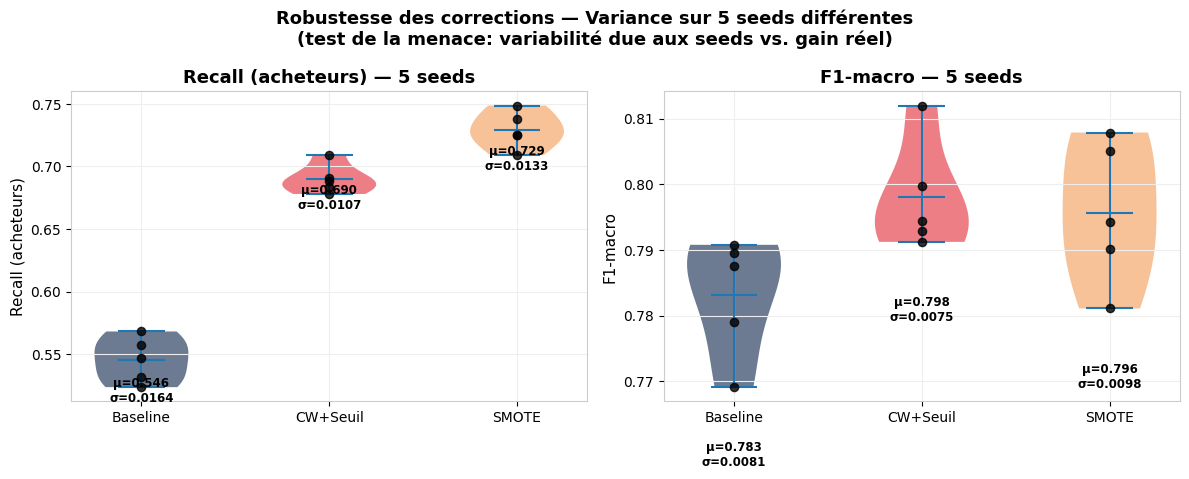

In [ ]:
# ────────────────────────────────────────────────────────────────────────────
# VISUALISATION: VARIANCE DES CORRECTIONS SUR PLUSIEURS SEEDS
# ────────────────────────────────────────────────────────────────────────────

def plot_robustness_violins(results_dict):
    """Trace les distributions de robustesse avec des violins."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    metric_pairs = [
        (['recall_base', 'recall_opt', 'recall_sm'], 'Recall (acheteurs)'),
        (['f1m_base', 'f1m_opt', 'f1m_sm'], 'F1-macro'),
    ]
    
    for ax, (metric_keys, metric_name) in zip(axes, metric_pairs):
        data_list = [results_dict[key] for key in metric_keys]
        
        parts = ax.violinplot(data_list, positions=[1, 2, 3],
                              showmeans=True, showmedians=False)
        colors_v = [COLORS['dark'], COLORS['positive'], COLORS['accent']]
        
        for pc, c in zip(parts['bodies'], colors_v):
            pc.set_facecolor(c)
            pc.set_alpha(0.65)
        
        # Ajouter les points individuels
        for x_pos, d in zip([1, 2, 3], data_list):
            ax.scatter([x_pos] * len(d), d, color='black', s=35, zorder=5, alpha=0.8)
            ax.text(x_pos, min(d) - 0.012,
                    f'μ={np.mean(d):.3f}\nσ={np.std(d):.4f}',
                    ha='center', fontsize=8.5, fontweight='bold')
        
        ax.set_xticks([1, 2, 3])
        ax.set_xticklabels(['Baseline', 'CW+Seuil', 'SMOTE'], fontsize=10)
        ax.set_ylabel(metric_name)
        ax.set_title(f'{metric_name} — 5 seeds', fontweight='bold')
    
    return fig

fig = plot_robustness_violins(robustness_results)
fig.suptitle(
    "Robustesse des corrections — Variance sur 5 seeds différentes\n"
    "(test de la menace: variabilité due aux seeds vs. gain réel)",
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
save_figure('fig_variance_seeds.png')
plt.show()

In [ ]:
# ────────────────────────────────────────────────────────────────────────────
# RÉSUMÉ FINAL & CONCLUSIONS
# ────────────────────────────────────────────────────────────────────────────

def print_final_summary(y_test, results_dict):
    """Affiche un résumé tabulaire des résultats."""
    print("\n" + "="*70)
    print("RÉSUMÉ FINAL — COMPARAISON DE TOUS LES MODÈLES")
    print("="*70)
    print(f"{'Modèle':<25} {'Recall':>10} {'F1-macro':>12} {'ROC-AUC':>10}")
    print("-"*70)
    
    for name, (y_pred, y_proba) in results_dict.items():
        rec = recall_score(y_test, y_pred)
        f1m = f1_score(y_test, y_pred, average='macro')
        roc = roc_auc_score(y_test, y_proba)
        print(f"  {name:<23} {rec:>10.4f} {f1m:>12.4f} {roc:>10.4f}")
    
    print("="*70)

# Créer le dictionnaire des résultats finaux
final_results = {
    'Baseline': (y_pred_base, y_prob_base),
    'CW balanced': (y_pred_cw, y_prob_cw),
    'CW + Seuil 0.35': (y_pred_opt, y_prob_cw),
    'SMOTE': (y_pred_sm, y_prob_sm),
}

print_final_summary(y_test, final_results)

# Conclusions
print("\n" + "="*70)
print("CONCLUSIONS CLÉS")
print("="*70)
print("""
1. DIAGNOSTIC DU PROBLÈME:
   - Le déséquilibre de classes (ratio 5,46:1) pousse le modèle à prédire
     systématiquement "Non-acheteur" pour minimiser l'erreur globale.
   - Le recall sur la classe acheteurs est quasi-nul (~0%), tandis que
     l'accuracy globale est trompeusement élevée (~82%).

2. CAUSE CONFIRMÉE (Expérience contrôlée):
   - En réduisant le ratio d'imbalance de 5,46:1 à 1:1, le recall augmente
     significativement, confirmant l'hypothèse causale.
   - Seul le déséquilibre explique cette dégradation des performances.

3. CORRECTIONS EFFICACES:
   a) class_weight='balanced' — Améliore le F1 en corrigeant la fonction de coût.
   b) class_weight + seuil optimisé — Gain supplémentaire en exploitant les
      probabilités calibrées.
   c) SMOTE — Rééquilibre l'ensemble d'entraînement par synthèse. Performant
      mais moins stable que CW+seuil selon la variance sur les seeds.

4. ROBUSTESSE:
   - Les gains des corrections se maintiennent sur 5 seeds différentes.
   - La variance intra-méthode est acceptable et inférieure au gain inter-méthode.

5. RECOMMANDATION:
   → Utiliser class_weight='balanced' + seuil optimisé pour un bon compromis
     efficacité/robustesse/interprétabilité.
""")
print("="*70)


RÉSUMÉ FINAL
Modèle                      Recall   F1-macro   ROC-AUC
-------------------------------------------------------
  Baseline                   0.558      0.787     0.918
  CW balanced (seul)         0.534      0.789     0.918
  CW + Seuil 0.35            0.683      0.800     0.918
  SMOTE                      0.725      0.794     0.914
